In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("weight-height.csv")

In [7]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [9]:
df.shape

(10000, 3)

In [11]:
df.isnull().sum()

Gender    0
Height    0
Weight    0
dtype: int64

In [15]:
df.describe()
#we are working on height column.

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


<Axes: xlabel='Weight', ylabel='Density'>

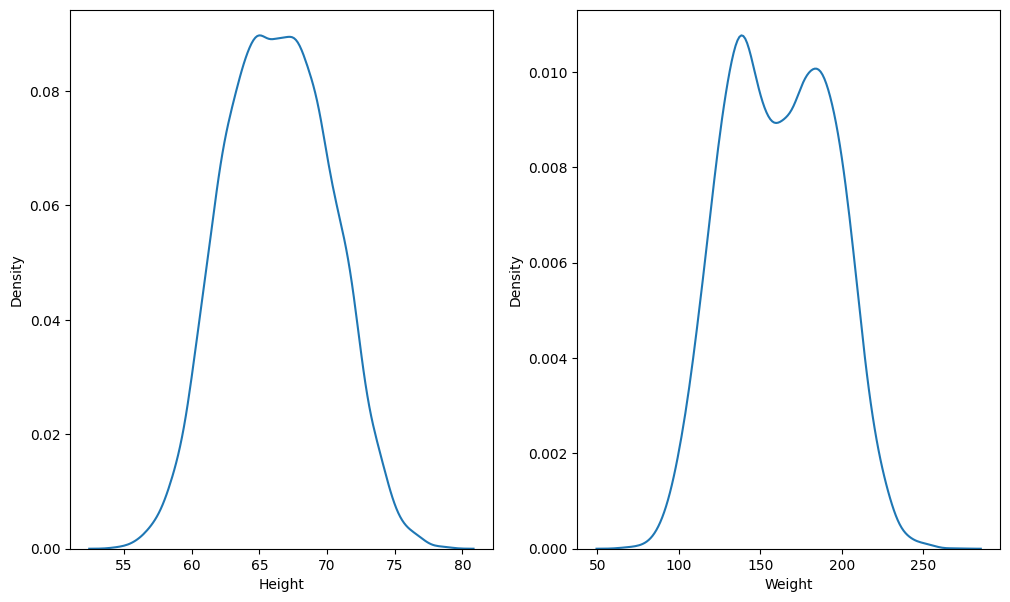

In [17]:
fig,ax=plt.subplots(1,2,figsize=(12,7))

sns.kdeplot(data=df,x="Height",ax=ax[0])

sns.kdeplot(data=df,x="Weight",ax=ax[1])

In [19]:
df["Height"].skew()

np.float64(0.04936908937689042)

In [21]:
df["Weight"].skew()

np.float64(0.03295450444592442)

<Axes: xlabel='Height'>

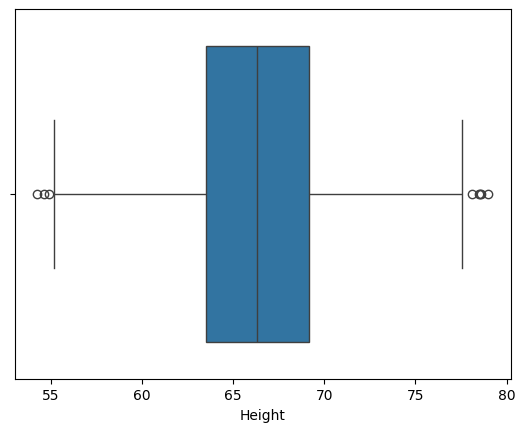

In [23]:
sns.boxplot(data=df,x="Height")

<Axes: xlabel='Weight'>

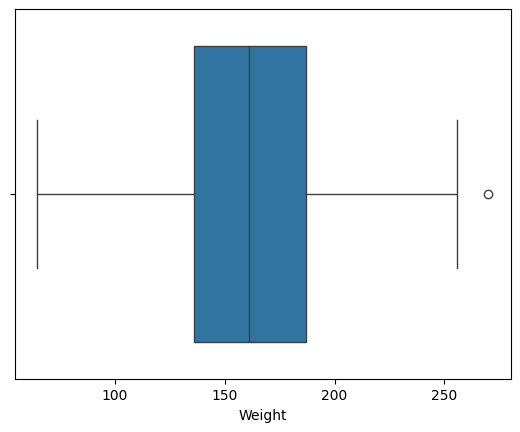

In [25]:
sns.boxplot(data=df,x="Weight")

In [26]:
#we will work on Height column


In [28]:
df["Height"].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [30]:
upper_limit=df["Height"].quantile(0.99)
lower_limit=df["Height"].quantile(0.01)

In [32]:
upper_limit

np.float64(74.7857900583366)

In [33]:
lower_limit

np.float64(58.13441158671655)

In [34]:
#finding outlier

In [38]:
df[(df["Height"]>=74.78) | (df["Height"]<=58.13)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [40]:
#Trimming


In [41]:
new_df=df[(df["Height"]<=74.78) & (df["Height"]>=58.13)]

In [43]:
new_df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [45]:
new_df.shape

(9799, 3)

<Axes: xlabel='Height'>

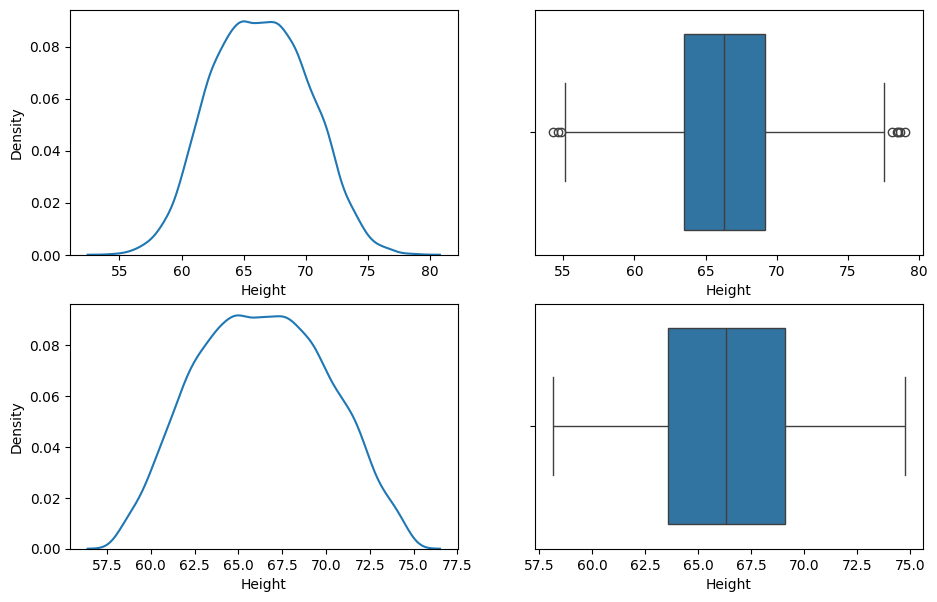

In [50]:
fig,ax=plt.subplots(2,2,figsize=(11,7))

sns.kdeplot(data=df,x="Height",ax=ax[0][0])
sns.boxplot(data=df,x="Height",ax=ax[0][1])

sns.kdeplot(data=new_df,x="Height",ax=ax[1][0])
sns.boxplot(data=new_df,x="Height",ax=ax[1][1])


In [52]:
#CAPPING

In [54]:
new_cap=df.copy()

In [56]:
new_cap.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [58]:
new_cap.shape

(10000, 3)

In [60]:
new_cap["Height"]=new_cap["Height"].clip(lower=lower_limit,upper=upper_limit)

In [62]:
new_cap.shape

(10000, 3)

In [65]:
new_cap["Height"].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

<Axes: xlabel='Height'>

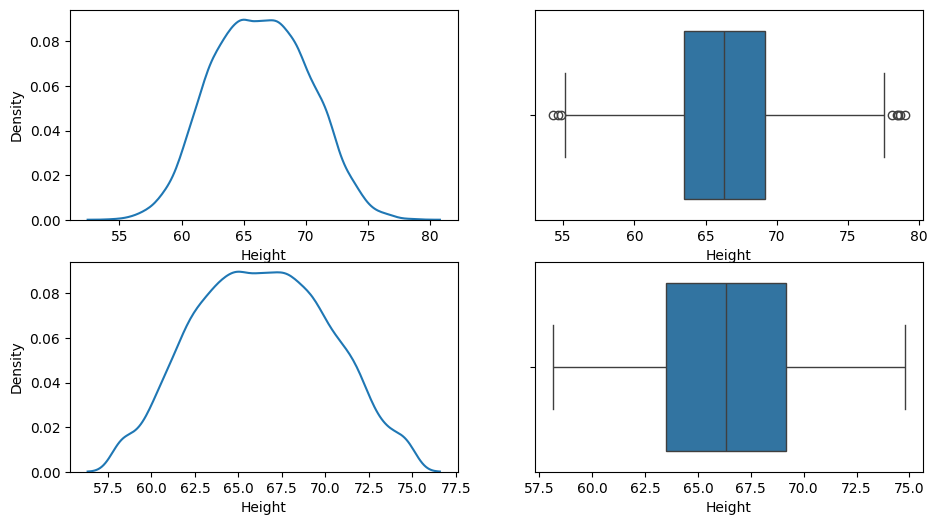

In [66]:
fig,ax=plt.subplots(2,2,figsize=(11,6))

sns.kdeplot(data=df,x="Height",ax=ax[0][0])
sns.boxplot(data=df,x="Height",ax=ax[0][1])
sns.kdeplot(data=new_cap,x="Height",ax=ax[1][0])
sns.boxplot(data=new_cap,x="Height",ax=ax[1][1])